# Experimento 4 · Comparar pesos sobre las mediciones reales

**Pregunta:** ¿repartir las contribuciones de mayor peso reduce los cruces locales del umbral de 155 ppb bajo el mismo presupuesto de ataque?

Continuamos los ejercicios 01–03. El archivo `data/raw/2025O3.xls` se usa sin interpolación: cada medición válida estación–hora cuenta como una oportunidad de ataque. Los faltantes se excluyen y los ceros se conservan.

Este notebook tiene **una sola celda ejecutable** y puede ejecutarse con `Python (lorawan11 .venv)`. El cálculo está en `comparar_pesos.py`, para poder comprobarlo con pruebas independientes. Guarda sus CSV, metadatos y gráficas en `resultados/04/`. Al repetirlo reemplaza exclusivamente esos productos del experimento 04.

**Alcance:** laboratorio de representación, sin cifrado, LSTM ni ataque LoRaWAN de extremo a extremo. Una lectura que cruza 155 no equivale a fabricar o anular una contingencia de toda la red.

## 1. Fijar la propuesta antes de comparar resultados

Conservamos un campo de valor de 16 bits dentro del payload de cuatro bytes y resolución de 1 ppb. El dominio elegido para V1 y V2 es **0–255 ppb**; no se deduce del máximo observado ni se propone todavía como rango definitivo del sensor.

**V1** dividía la contribución de 32 en dos posiciones de 16. **V2**, definida aquí como extensión de esa idea, conserva esa división y además reparte 64 en dos posiciones de 32 y 128 en cuatro posiciones de 32.

| Contribución original | Posiciones en V1 | Posiciones en V2 |
|---:|---|---|
| 1, 2, 4, 8, 16 | Bits 0–4, sin cambios | Bits 0–4, sin cambios |
| 32 | Bits 5 y 8: 16 + 16 | Bits 5 y 8: 16 + 16 |
| 64 | Bit 6: 64 | Bits 6 y 9: 32 + 32 |
| 128 | Bit 7: 128 | Bits 7, 10, 11 y 12: 32 + 32 + 32 + 32 |
| Reservados en cero | Bits 9–15 | Bits 13–15 |

El codificador enciende **todos los fragmentos** de una contribución si su bit original era 1; de lo contrario los apaga. El decodificador suma los pesos de las posiciones encendidas. No exige coincidencia entre fragmentos ni los corrige. Una posición reservada encendida produce rechazo.

Esto recupera exactamente los 256 valores legítimos. Un flip en una posición activa de V2 cambia la lectura como máximo 32 ppb; dos flips, como máximo 64. **No se afirma que V2 sea óptima:** es una extensión sencilla para poner a prueba la hipótesis. Emisor y receptor deben compartir el formato; V1/V2 no son compatibles con un decodificador CayenneLPP genérico.

## 2. Un control para no atribuir toda mejora a los pesos

Comparamos cuatro variantes:

- **actual:** interpretación original con signo de 16 bits, incluyendo negativos o valores muy altos después de un ataque, igual que `src/encoding/cayenne.py`.
- **binario_8_control:** los mismos bytes originales, pero el receptor rechaza valores fuera de 0–255. Este control no redistribuye pesos.
- **v1:** propuesta del notebook 02, nueve posiciones activas.
- **v2:** nueva propuesta, trece posiciones activas.

El control permite distinguir el efecto de rechazar valores inválidos del efecto de repartir pesos. Para V1/V2 todos los patrones que no activan bits reservados suman entre 0 y 255. Los rechazos **no cuentan como cruces**, pero se reportan por separado: se perdió una lectura. El cociente `cruce o rechazo` también se incluye; combina dos consecuencias distintas y no impone que tengan el mismo coste operativo.

## 3. El mismo adversario y los mismos mensajes

En cada escenario se altera **un solo mensaje**, exclusivamente en su campo de valor. Se enumeran las 16 posiciones para un flip y las 120 parejas de posiciones distintas para dos flips. No se mezclan ambos presupuestos ni se interpreta invertir dos veces el mismo bit como un ataque de dos bits.

El atacante conoce la codificación; no suponemos que su secreto la proteja. Presentamos dos políticas:

1. **Uniforme:** elige al azar entre todas las máscaras físicas de ese presupuesto, independientemente del dato. Se calcula exactamente el promedio, sin muestreo ni semillas. No se asume que un atacante real necesariamente actúe así.
2. **Peor máscara fija:** se identifica retrospectivamente la posición o pareja con más cruces en todo el conjunto y se aplica la misma a todos sus mensajes. Es un análisis de sensibilidad, no una selección distinta para cada valor. La tabla por estación calcula su peor máscara dentro de cada estación, que puede diferir de la global.

Agrupar las mediciones por valor exacto conserva los conteos de cruces locales. No conserva el contexto que se necesitaría para evaluar máximos horarios o diarios de la red.

**Denominadores:** `pct_cruces_uniforme` usa todos los mensajes × máscaras; `pct_arriba_dado_bajo` solo originales <155 × máscaras; `pct_abajo_dado_alto` solo originales ≥155 × máscaras. Los rechazos permanecen en esos denominadores. Si una estación no tiene originales altos, su tasa de cruces abajo se deja vacía, no se convierte en 0 %.

## 4. Ejecutar y leer los resultados

Las primeras tablas separan el promedio uniforme de la peor máscara fija. La siguiente muestra cruces y rechazos como conteos de **escenarios contrafactuales**, no como ataques realmente observados ni muestras independientes. La tabla por estación permite ver si el resultado global oculta diferencias de cobertura o concentración.

Antes de ejecutar, escribe tu predicción: **¿V1 necesariamente reducirá los cruces hacia abajo? ¿Qué cambia al sustituir una posición de 32 por dos de 16 cerca de 155 ppb?**

Lecturas: 218,823 | estaciones: 33
Originales ≥155 ppb: 25 (no son contingencias independientes)
Dataset SHA-256: 91c11b286ba44f8254ca74e0948e22f2a3ff46b12728ef9175141f1fb026a37f


### 1 flip(s) por mensaje

,formato,n_mascaras,pct_cruces_uniforme,pct_arriba_dado_bajo,pct_abajo_dado_alto,pct_rechazos
0,actual,16,46.7285,46.7311,24.25,0.00
2,binario_8_control,16,2.9828,2.9811,18.00,50.00
4,v1,16,2.9757,2.9736,21.25,43.75
6,v2,16,0.1008,0.0962,40.00,18.75


,formato,peor_mascara_fija,pct_cruces_peor_mascara_fija,delta_max_aceptados,pct_cruce_o_rechazo
0,actual,8,99.9886,32768.0,46.7285
2,binario_8_control,7,46.9882,128.0,52.9828
4,v1,7,46.9882,128.0,46.7257
6,v2,6,0.3153,32.0,18.8508


### 2 flip(s) por mensaje

...

,formato,peor_mascara_fija,pct_cruces_peor_mascara_fija,delta_max_aceptados,pct_cruce_o_rechazo
1,actual,0+8,99.9886,32896.0,67.5748
3,binario_8_control,6+7,88.2942,192.0,80.0807
5,v1,6+7,88.2942,192.0,73.8203
7,v2,7+10,4.0023,64.0,35.3042


### Conteos auditables: una fila por formato y presupuesto

,formato,n_flips,n_escenarios,cruces_arriba,cruces_abajo,rechazos,fuera_0_255
0,actual,1,3501168,1635948,97,0,1750584
1,actual,2,26258760,17743577,718,0,20131716
2,binario_8_control,1,3501168,104362,72,1750584,0
3,binario_8_control,2,26258760,896131,343,20131716,0
4,v1,1,3501168,104098,85,1531761,0
5,v1,2,26258760,1002753,402,18381132,0
6,v2,1,3501168,3368,160,656469,0
7,v2,2,26258760,78815,1052,9190566,0


### Un flip: resultados por estación (control, V1 y V2)

formato,binario_8_control,v1,v2
station,,,
ACO,3.1031,3.0976,0.0197
AJM,4.3770,4.3722,0.2173
AJU,3.5069,3.4992,0.0335
ATI,2.7793,2.7777,0.0593
BJU,3.2161,3.2018,0.3252
CAM,2.4060,2.3989,0.1254
CCA,3.1040,3.0937,0.1700
CHO,3.5032,3.5032,0.0083
CUA,4.4098,4.3840,0.2723


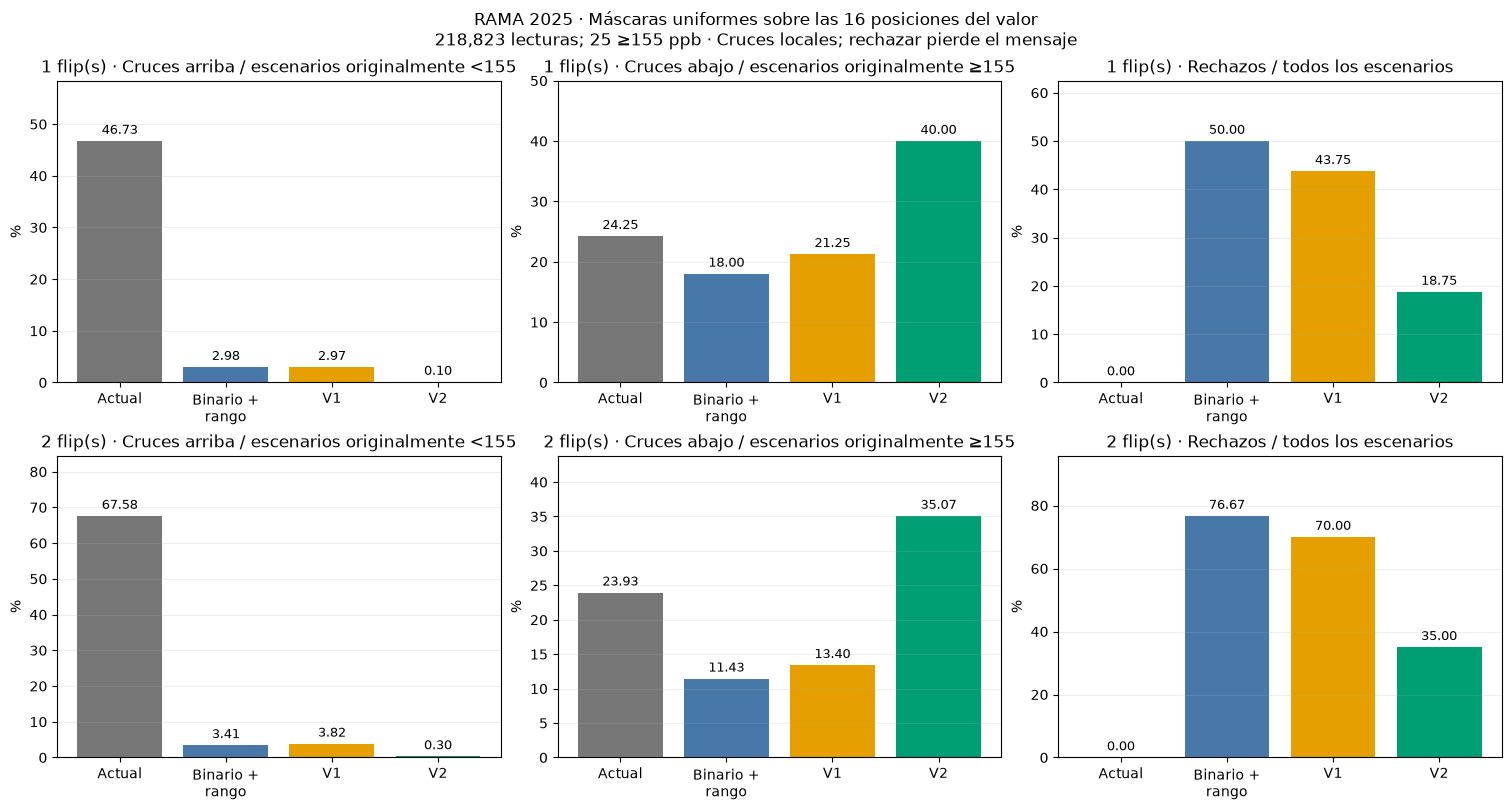

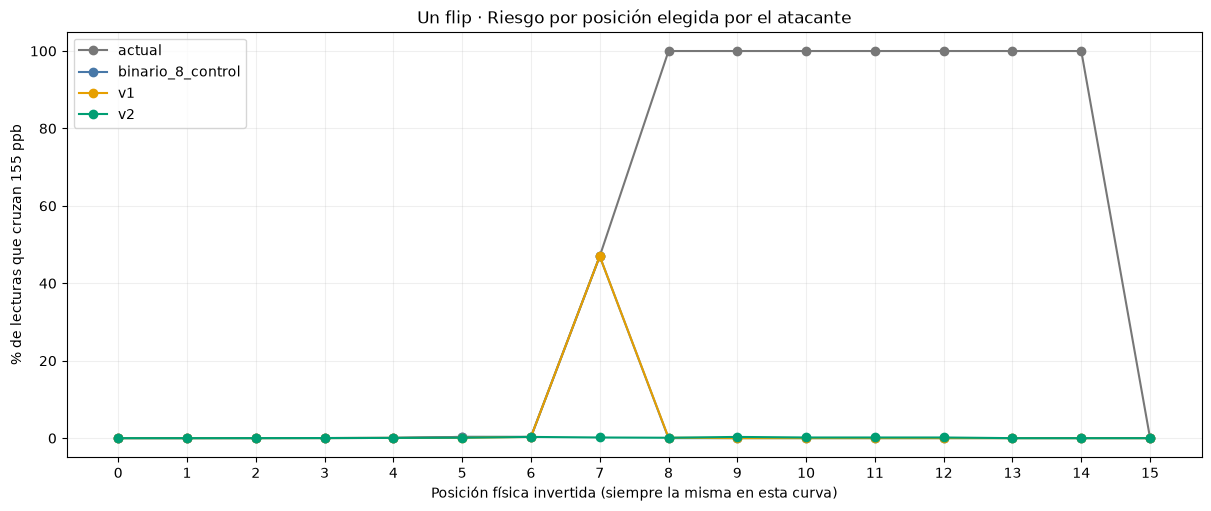

Productos guardados en: experiments/cayenne_mod/resultados/04


In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

actual = Path.cwd().resolve()
RAIZ = next((p for p in (actual, *actual.parents)
             if (p / "experiments/cayenne_mod/comparar_pesos.py").is_file()), None)
if RAIZ is None:
    raise RuntimeError("Abre el notebook dentro del repositorio de la tesis.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from experiments.cayenne_mod import comparar_pesos
comparar_pesos = importlib.reload(comparar_pesos)

DESTINO = RAIZ / "experiments/cayenne_mod/resultados/04"
resumen, por_mascara, metadatos = comparar_pesos.ejecutar(RAIZ, DESTINO)
globales = resumen.loc[resumen.station.eq("TODAS")].copy()
print(f"Lecturas: {metadatos['n_validos']:,} | estaciones: {metadatos['n_estaciones']}")
print(f"Originales ≥155 ppb: {metadatos['n_sobre_umbral']} (no son contingencias independientes)")
print(f"Dataset SHA-256: {metadatos['sha256_dataset']}")

for presupuesto in (1, 2):
    display(Markdown(f"### {presupuesto} flip(s) por mensaje"))
    tabla = globales.loc[globales.n_flips.eq(presupuesto)]
    display(tabla[["formato", "n_mascaras", "pct_cruces_uniforme",
                   "pct_arriba_dado_bajo", "pct_abajo_dado_alto", "pct_rechazos"]].round(4))
    display(tabla[["formato", "peor_mascara_fija", "pct_cruces_peor_mascara_fija",
                   "delta_max_aceptados", "pct_cruce_o_rechazo"]].round(4))

display(Markdown("### Conteos auditables: una fila por formato y presupuesto"))
display(globales[["formato", "n_flips", "n_escenarios", "cruces_arriba",
                  "cruces_abajo", "rechazos", "fuera_0_255"]])
display(Markdown("### Un flip: resultados por estación (control, V1 y V2)"))
estaciones = resumen.loc[resumen.station.ne("TODAS") & resumen.n_flips.eq(1)
                         & resumen.formato.ne("actual")]
display(estaciones.pivot(index="station", columns="formato", values="pct_cruces_uniforme").round(4))
comparar_pesos.graficar(resumen, por_mascara, DESTINO)
plt.show()
print(f"Productos guardados en: {DESTINO.relative_to(RAIZ)}")

## Resultado de esta ejecución: una mejora y un límite

Con **un flip uniforme** sobre las 16 posiciones, V2 reduce los cruces hacia arriba de **2.9811 % a 0.0962 %**, frente al control binario con rango. Pero, entre las 25 lecturas originalmente ≥155, los cruces hacia abajo aumentan de **72/400 = 18 %** a **160/400 = 40 %**. Esos 400 son escenarios (25 lecturas × 16 posiciones), no 400 observaciones independientes.

Para entenderlo, toma 160 ppb: el control tiene dos posiciones que pueden bajarlo de 155 (bits 5 y 7); V1 tiene tres (5, 7, 8); V2 tiene seis (5, 7, 8, 10, 11, 12). Repartir la contribución crea más posiciones capaces de restar lo suficiente para cruzar el umbral, aunque cada una pese menos.

**La tasa global mejora y el ocultamiento de lecturas altas empeora bajo esta política.** Por eso no elegimos una representación usando solo el promedio global. Los dos flips muestran el mismo compromiso y se presentan por separado.

Esta lectura de resultados corresponde a RAMA 2025 y los parámetros originales del experimento 04; revisarla si se cambia el protocolo. El [resumen para tu junta](avance_junta_04.md) reúne los conteos, la explicación y los límites.

## 5. Qué podemos concluir y qué queda pendiente

- Reducir el desplazamiento máximo no garantiza reducir todos los cambios de decisión: importa cuán cerca del umbral estaba la lectura, el sentido del flip y cuántas posiciones pueden producirlo.
- El promedio uniforme depende del modelo de atacante. La peor máscara fija revela si queda una posición especialmente perjudicial.
- Una lectura rechazada puede tener consecuencias operativas. Aquí no se modela cómo el sistema responde a su ausencia ni se usa como prueba de corrección del dato.
- 2025 ya orientó la exploración; estos resultados son **exploratorios**. No hay validación independiente con otro año y solo hay pocas lecturas ≥155, posiblemente correlacionadas temporalmente.
- Los formatos restringen el rango a 0–255 y modifican su interpretación. Falta acordar el rango definitivo, evaluar otras distribuciones y tratar la integración con el formato de aplicación.
- No se midieron energía, latencia, seguridad criptográfica, impacto sobre toda la red ni detección LSTM. La relación entre menor perturbación y menor detectabilidad sigue pendiente.

**Para continuar:** interpretar primero el compromiso entre cruces y rechazos, fijar una candidata y un modelo de atacante, validar con otro año sin reajustar sus pesos y después evaluar daño no detectado con el LSTM guardado.

## Tus observaciones para la junta

- ¿Qué mejora se debe al filtro de rango y qué mejora persiste al comparar V2 con ese control?
- ¿Qué sucede con V1 cerca del umbral, aunque su delta sea menor?
- ¿Qué coste tendría rechazar una medición para tu sistema?
- ¿Qué rango debe preservar el formato final, más allá de lo observado en 2025?

Escribe aquí tus notas antes de proponer una V3.